<a href="https://colab.research.google.com/github/gitmystuff/DSChunks/blob/main/Singular_Value_Decomposition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/gitmystuff/DSChunks/blob/main/SVD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Singular Value Decomposition (SVD)

* SVD breaks any matrix $A$ into three simpler matrices: $A = U \Sigma V^T$
* $U$ and $V$ are orthogonal (rotation) matrices; $\Sigma$ is diagonal and holds the **singular values**, ranked largest to smallest
* Singular values measure how much "structure" each direction of the data contributes -- the first few usually capture most of it
* Keeping only the top $k$ singular values gives a **low-rank approximation** of $A$ -- a smaller, simpler matrix that still resembles the original closely
* This is the same idea underneath **PCA** (which runs SVD on a centered/standardized data matrix), and it's used for image compression, noise reduction, recommendation systems, and topic modeling (LSA)
* Rule of thumb: SVD works well on data with real structure/redundancy; it does little for pure random noise, since noise has no structure to compress


### A small example: decomposing and reconstructing a matrix

In [1]:
import numpy as np

A = np.array([
    [4, 0],
    [3, -5]
], dtype=float)

U, singular_values, Vt = np.linalg.svd(A)

print("U (left singular vectors):\n", np.round(U, 3))
print("\nSingular values:", np.round(singular_values, 3))
print("\nV^T (right singular vectors):\n", np.round(Vt, 3))

# Reconstruct A from its pieces
Sigma = np.diag(singular_values)
A_reconstructed = U @ Sigma @ Vt
print("\nReconstructed A:\n", np.round(A_reconstructed, 3))


U (left singular vectors):
 [[-0.447 -0.894]
 [-0.894  0.447]]

Singular values: [6.325 3.162]

V^T (right singular vectors):
 [[-0.707  0.707]
 [-0.707 -0.707]]

Reconstructed A:
 [[ 4. -0.]
 [ 3. -5.]]


### Low-rank approximation: keeping only the top singular values

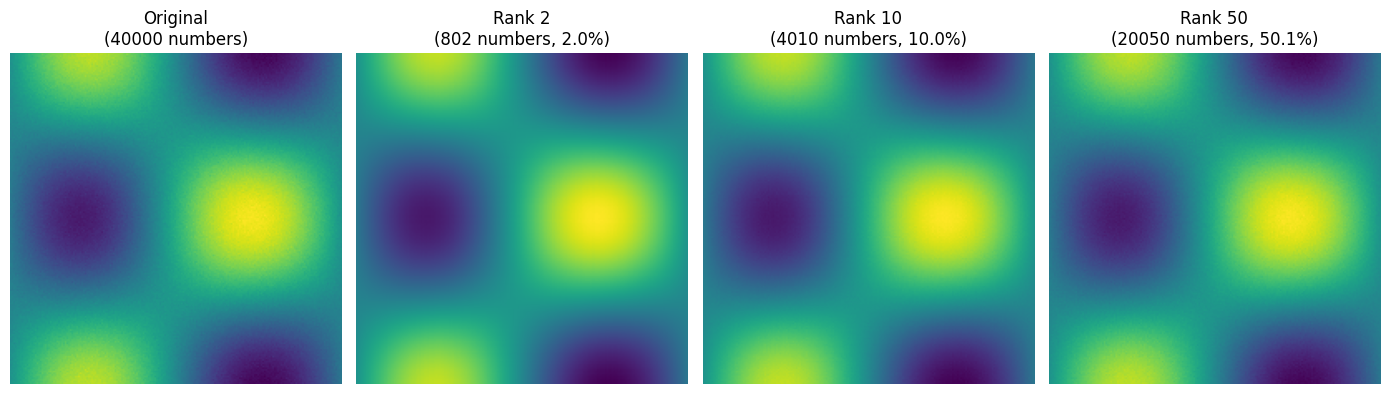

In [2]:
# Build a matrix with real structure (not random noise) -- a synthetic
# "image" made of a couple of overlapping patterns, plus a little noise.
size = 200
x = np.linspace(-3, 3, size)
y = np.linspace(-3, 3, size)
X_grid, Y_grid = np.meshgrid(x, y)

rng = np.random.default_rng(0)
image = np.sin(X_grid) * np.cos(Y_grid) + 0.4 * np.exp(-(X_grid**2 + Y_grid**2) / 3)
image += rng.normal(0, 0.02, size=image.shape)   # a small amount of noise

U, singular_values, Vt = np.linalg.svd(image, full_matrices=False)

import matplotlib.pyplot as plt

ranks = [2, 10, 50]
fig, axes = plt.subplots(1, len(ranks) + 1, figsize=(14, 4))

axes[0].imshow(image, cmap="viridis")
axes[0].set_title(f"Original\n({image.size} numbers)")
axes[0].axis("off")

for ax, k in zip(axes[1:], ranks):
    approx = U[:, :k] @ np.diag(singular_values[:k]) @ Vt[:k, :]
    numbers_stored = k * (U.shape[0] + Vt.shape[1] + 1)
    ax.imshow(approx, cmap="viridis")
    ax.set_title(f"Rank {k}\n({numbers_stored} numbers, {numbers_stored / image.size:.1%})")
    ax.axis("off")

plt.tight_layout()
plt.show()


This is showing how much of an image's visual information can be captured with a much smaller amount of stored data, using SVD.

- **"Original" (40,000 numbers)** — this is the full image: 200×200 pixels, meaning 40,000 individual numbers, one per pixel.
- **"Rank 2" (802 numbers, 2.0%)** — instead of storing all 40,000 pixel values, this reconstructs the image using only the *top 2* singular values/vectors from the SVD decomposition — just 802 numbers, or 2% of the original data. And yet visually it already looks almost identical to the original.
- **"Rank 10"** and **"Rank 50"** — same idea, keeping a few more singular values each time (10% and ~50% of the original data size, respectively) — but notice they barely look any different from Rank 2. The extra numbers aren't adding much you can see.

**Why does Rank 2 already look so complete?** Because the synthetic image was built to have very simple, repetitive structure — it's essentially a smooth wave pattern (`sin(x) * cos(y)` plus one soft blob), which only takes a couple of "directions" to describe fully. SVD ranks those directions by how much of the image's pattern they explain, and it turns out almost the entire picture is explained by just the top 2. Adding more (Rank 10, Rank 50) mostly just captures the tiny bit of random noise we added on purpose — which is genuinely not worth storing, since noise has no real structure to compress.

**The takeaway the image is meant to demonstrate:** when data has real underlying structure (as opposed to pure randomness), SVD can represent almost all of that structure using a small fraction of the original storage. That's the whole practical value of SVD — and it's exactly what PCA, which is built on top of SVD, exploits when it reduces a high-dimensional dataset down to just a couple of components.


### How much does each singular value matter?

The plot below shows why keeping only the top few singular values is usually enough: they drop off fast, and the smallest ones contribute almost nothing to the reconstruction.


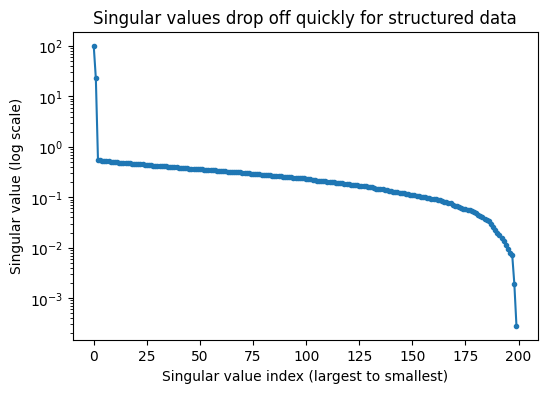

Top 10 singular values capture 74.8% of the total singular value mass


In [3]:
plt.figure(figsize=(6, 4))
plt.plot(singular_values, marker='o', markersize=3)
plt.yscale('log')
plt.xlabel('Singular value index (largest to smallest)')
plt.ylabel('Singular value (log scale)')
plt.title('Singular values drop off quickly for structured data')
plt.show()

print(f"Top 10 singular values capture "
      f"{singular_values[:10].sum() / singular_values.sum():.1%} of the total singular value mass")
